In [1]:
# Supply chain analysis of feedstock cost impact on MJSP
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, additional_rcf
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank


In [2]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

In [4]:
etoh_system = create_cellulosic_ethanol_system(ins=poplar_in, add_denaturant=False)
etoh_system.simulate()

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()


# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\pressure_vessel.py:104: CostWarning: <RefluxDrum: reflux_drum> Vertical vessel length (9 ft) is out of bounds (12 to 40 ft) for cost correlation
  return method(pressure, diameter, length)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\tank_design.py:107: CostWarning: volume (0 gal) is below the lower bound (30000 gal) for purchase cost estimation
  warn(f"volume ({V_total:.5g} {V_units}) is below "
c:\Users\hwadg\

In [5]:
# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.

etoh_ww = [F.pretreatment_wastewater, F.unit.S401.outs[1]]

etoh_solids = [F.unit.S401.outs[0]]

WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.ETJ_WW_OUTS] + etoh_ww)
F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)

BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])

gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF




In [6]:
h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

h2_storage = HydrogenStorageTank('H2_TK', ins=h2_etj)


In [7]:
etoh_etj_system = bst.System(
    'Cellulosic_ETJ',
    path=(etoh_system, nh3_splitter, etj_system, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_storage, BT],
)

etoh_etj_system.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:986: RuntimeWarning: the purchase cost item, 'Total Cost', has no defined bare-module factor in the 'HydrogenStorageTank.F_BM' dictionary; bare-module factor now has a default value of 1
  warn(f"the purchase cost item, '{name}', has "


In [8]:
F.ETJ_H2_IN.price = prices['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = prices['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = prices['renewable_diesel']    # 1.888 USD/kg
F.sulfuric_acid.price = prices['H2SO4']
F.ammonia.price = prices['NH3']
F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 
#F.FOD_lime.price = prices['FOD_lime']


integrated_tea = create_cellulosic_ethanol_tea(etoh_etj_system)

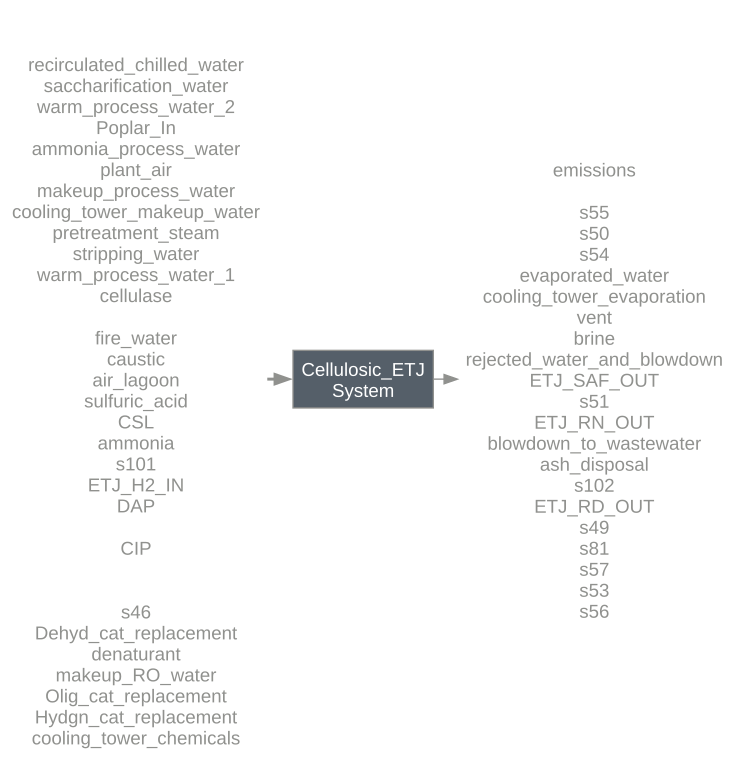

System: Cellulosic_ETJ
Highest convergence error among components in recycle
streams {ETJ_SPLIT1-1, ETJ_SPLIT2-0, ETJ_SPLIT3-0} after 1 loops:
- flow rate   9.53e-03 kmol/hr (0.004%)
- temperature 1.57e-09 K (2.5e-10%)
ins...
[0] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water     925
                    Sucrose   0.243
                    Extract   7.4
                    Acetate   48.6
                    Ash       1e+03
                    Lignin    156
                    Glucan    238
                    Xylan     84.5
                    Arabinan  1.26
                    Mannan    19
                    Galactan  7.2
[1] warm_process_water_1  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  1.3e+03
[2] pretreatment_steam  
    phase: 'g', T: 541.15 K, P: 1.31722e+06 Pa
    flow (kmol/hr): Water  1.76e+03
[3] warm_process_water_2  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  8.79e+03
[4] ammonia_process

In [9]:
etoh_etj_system

In [10]:
integrated_tea.operating_days = 330
mjsp = round(((integrated_tea.solve_price(F.ETJ_SAF_OUT)*F.ETJ_SAF_OUT.rho)/264.172),2)

print(f'The MSP for SAF blend is  {mjsp} USD/gal')

The MSP for SAF blend is  8.65 USD/gal
